## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import torch

from vanilla_rnn import GradientExperiments

## 01 Creating a matrix with a given spectral radius

In [2]:
# Create an instance of the GradientExperiments class
ge = GradientExperiments()

# Create a vanishing gradient matrix with a spectral radius of 0.5
vanishing_matrix = ge.create_init_matrix(
    spectral_radius=0.5,
)

# Verify the spectral radius of the created matrix
eigenvalues = torch.linalg.eigvalsh(vanishing_matrix)
spectral_radius = eigenvalues.abs().max()

print(f"Eigenvalues: {eigenvalues}")
print(f"Spectral radius: {spectral_radius.item():.4f}")

Eigenvalues: tensor([0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000])
Spectral radius: 0.5000


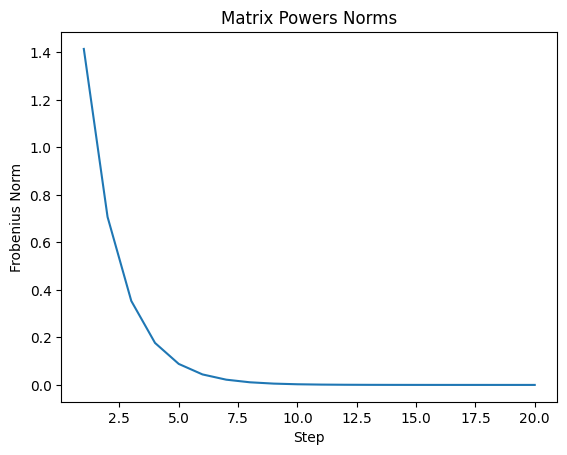

Matrix power 0:  1.414214
Matrix power 5:  0.044194
Matrix power 10:  0.001381
Matrix power 15:  0.000043


In [6]:
# Set vanishing_matrix to device
vanishing_matrix = vanishing_matrix.to(ge.device)

# Inspect matrix powers to see the vanishing effect
matrix_powers = ge.inspect_matrix_powers(vanishing_matrix, number_of_steps=20)

# Print some of the matrix powers to observe the vanishing effect
for i, power in enumerate(matrix_powers):
    if i % 5 == 0:  # Print every 5th power for brevity
        print(f"Matrix power {i}: {power: .6f}")